In [1]:
import pandas as pd
df = pd.read_csv("D:/tiger analytics/Python/consumer behavior/ecommerce_customer_behavior_dataset_v2.csv") 

In [2]:
print(df.head())

       Order_ID Customer_ID        Date  Age Gender      City  \
0  ORD_000001-1  CUST_00001  29-05-2023   40   Male    Ankara   
1  ORD_000001-2  CUST_00001  12-10-2023   40   Male    Ankara   
2  ORD_000001-3  CUST_00001  05-12-2023   40   Male    Ankara   
3  ORD_000002-1  CUST_00002  11-05-2023   33   Male  Istanbul   
4  ORD_000002-2  CUST_00002  16-06-2023   33   Male  Istanbul   

  Product_Category  Unit_Price  Quantity  Discount_Amount  Total_Amount  \
0            Books       29.18         1             0.00         29.18   
1    Home & Garden      644.40         1           138.05        506.35   
2           Sports      332.82         5             0.00       1664.10   
3             Food       69.30         5            71.05        275.45   
4           Beauty      178.15         3             0.00        534.45   

   Payment_Method Device_Type  Session_Duration_Minutes  Pages_Viewed  \
0  Digital Wallet      Mobile                        14             9   
1     Credit

In [3]:
rfm_df = df[['Customer_ID', 'Date', 'Total_Amount']]

In [4]:
rfm_df.head()

,Customer_ID,Date,Total_Amount
0,CUST_00001,29-05-2023,29.18
1,CUST_00001,12-10-2023,506.35
2,CUST_00001,05-12-2023,1664.10
3,CUST_00002,11-05-2023,275.45
4,CUST_00002,16-06-2023,534.45


In [8]:
rfm_df['Date'] = pd.to_datetime(rfm_df['Date'], errors='coerce')

C:\Users\91966\AppData\Local\Temp\ipykernel_12516\583579852.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  rfm_df['Date'] = pd.to_datetime(rfm_df['Date'], errors='coerce')
C:\Users\91966\AppData\Local\Temp\ipykernel_12516\583579852.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rfm_df['Date'] = pd.to_datetime(rfm_df['Date'], errors='coerce')


In [9]:
print(rfm_df['Date'].head())
print(rfm_df['Date'].dtype)

0   2023-05-29
1   2023-10-12
2   2023-12-05
3   2023-05-11
4   2023-06-16
Name: Date, dtype: datetime64[ns]
datetime64[ns]


In [18]:
snapshot_date = rfm_df['Date'].max() + pd.Timedelta(days=1)

# RFM aggregation
rfm = rfm_df.groupby('Customer_ID').agg({
    'Date': lambda x: (snapshot_date - x.max()).days,   # Recency
    'Customer_ID': 'count',                             # Frequency
    'Total_Amount': 'sum'                               # Monetary
})

# Rename columns
rfm.rename(columns={
    'Date': 'Recency',
    'Customer_ID': 'Frequency',
    'Total_Amount': 'Monetary'
}, inplace=True)

In [19]:
rfm_df.head()

,Customer_ID,Date,Total_Amount
0,CUST_00001,2023-05-29,29.18
1,CUST_00001,2023-10-12,506.35
2,CUST_00001,2023-12-05,1664.10
3,CUST_00002,2023-05-11,275.45
4,CUST_00002,2023-06-16,534.45


In [20]:
rfm.head()

,Recency,Frequency,Monetary
Customer_ID,,,
CUST_00001,112,3,2199.63
CUST_00002,284,2,809.90
CUST_00003,83,2,3030.81
CUST_00004,42,1,383.22
CUST_00005,279,3,2422.73


In [23]:
sorted_df = rfm.sort_values(by='Monetary', ascending=False)
print(sorted_df['Monetary'])

Customer_ID
CUST_01573    50628.15
CUST_00197    47324.23
CUST_03795    42480.02
CUST_00154    41613.83
CUST_04219    40608.39
                ...   
CUST_02655       20.97
CUST_00590       19.23
CUST_03932       16.98
CUST_00369       14.81
CUST_02640       14.28
Name: Monetary, Length: 5000, dtype: float64


In [24]:
import numpy as np

n_bins = 5   # number of R/F/M buckets

# Recency: lower is better → 5 = best (most recent), 1 = worst
rfm['R_Score'] = pd.qcut(
    rfm['Recency'].rank(method='first', ascending=True),
    q=n_bins,
    labels=[5,4,3,2,1]
)

# Frequency: higher is better → 5 = best (most frequent)
rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    q=n_bins,
    labels=[1,2,3,4,5]
)

# Monetary: higher is better → 5 = best (highest spender)
rfm['M_Score'] = pd.qcut(
    rfm['Monetary'].rank(method='first'),
    q=n_bins,
    labels=[1,2,3,4,5]
)

In [25]:
rfm['RFM_Score'] = (
    rfm['R_Score'].astype(int) * 100 +
    rfm['F_Score'].astype(int) * 10 +
    rfm['M_Score'].astype(int)
)

In [26]:
def segment_customer(row):
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']
    
    if r>=4 and f>=4 and m>=4:
        return "Champion"
    if r>=4 and f>=3:
        return "Loyal"
    if r>=3 and f>=2:
        return "Potential Loyalist"
    if r<=2 and f>=4:
        return "At Risk"
    if r<=2 and f<=2:
        return "Hibernating"
    if r>=4 and f<=2:
        return "New Customer"
    return "Others"

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

In [27]:
print(rfm.head())

             Recency  Frequency  Monetary R_Score F_Score M_Score  RFM_Score  \
Customer_ID                                                                    
CUST_00001       112          3   2199.63       3       3       3        333   
CUST_00002       284          2    809.90       1       1       2        112   
CUST_00003        83          2   3030.81       3       1       3        313   
CUST_00004        42          1    383.22       4       1       1        411   
CUST_00005       279          3   2422.73       1       3       3        133   

                        Segment  
Customer_ID                      
CUST_00001   Potential Loyalist  
CUST_00002          Hibernating  
CUST_00003               Others  
CUST_00004         New Customer  
CUST_00005               Others  


In [28]:
rfm['Segment'].value_counts()

Segment
Hibernating           1220
Potential Loyalist    1115
Champion               844
Loyal                  719
Others                 527
At Risk                395
New Customer           180
Name: count, dtype: int64

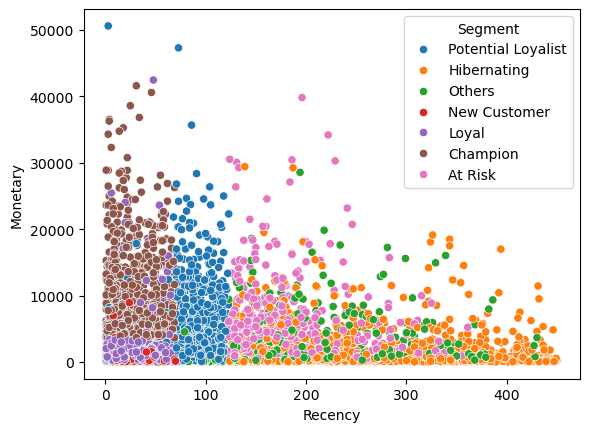

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='Segment')
plt.show()